In [1]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
import pandas as pd
import numpy as np
import os, math

os.chdir('../../../results/PlantCAD2_tasks/')

In [2]:
species  = ['arabidopsis_thaliana', 'brachypodium_distachyon', 'oryza_sativa']
contexts = ['c300', 'c600', 'c1000']
ckpts = [
    'pcv2-l24-d0768-checkpoints-lr-1e-4',
    'pcv2-l48-d1024-checkpoints-lr-1e-4',
    'pcv2-l48-d1536-checkpoints-lr-1e-4',
    'agront-checkpoints-lr-1e-4',
    'sup_pcv2-l24-d0768-checkpoints-lr-1e-4',
    'cnn-lstm-imbalance-lr-1e-3'
]
pcv2_alphas = [0.4, 0.7, 1.0]

In [3]:
records = []
for sp in species:
    for ctx in contexts:
        if sp == 'arabidopsis_thaliana':
            labels_path = f'accessible_angiosperm_{ctx}/data/valid.tsv'
        else:
            labels_path = f'accessible_angiosperm_{ctx}/data/test_{sp}.tsv'
        labs = pd.read_csv(labels_path, sep='\t')
        y_true = labs['Label']

        for k, ckpt in enumerate(ckpts):
            print(f"[{sp} | {ctx}] Processing model {k+1}/{len(ckpts)}: {ckpt}")
            if sp == 'arabidopsis_thaliana':
                scores_path = f'accessible_angiosperm_{ctx}/models/{ckpt}/valid_scores.tsv'
            else:
                scores_path = f'accessible_angiosperm_{ctx}/models/{ckpt}/test_{sp}_scores.tsv'
            preds = pd.read_csv(scores_path, sep='\t')
            y_scores = preds['probability_positive']
            ap = average_precision_score(y_true, y_scores)

            if 'agront' in ckpt.lower():
                color, alpha = 'gray', 1.0
            elif 'sup_pcv2' in ckpt.lower():
                color, alpha = 'C1', 1.0
            elif 'cnn' in ckpt.lower():
                color, alpha = 'C1', 0.5
            else:
                color, alpha = 'C0', pcv2_alphas[k]

            if 'cnn' in ckpt.lower():
                lab = ckpt.replace('-imbalance-lr-1e-3', '')
            else:
                lab = ckpt.replace('-checkpoints-lr-1e-4', '')

            records.append({
                'species': sp,
                'context': ctx,
                'model': lab,
                'ap': ap,
                'color': color,
                'alpha': alpha,
                'baseline': y_true.mean()
            })

df = pd.DataFrame(records)

[arabidopsis_thaliana | c300] Processing model 1/6: pcv2-l24-d0768-checkpoints-lr-1e-4
[arabidopsis_thaliana | c300] Processing model 2/6: pcv2-l48-d1024-checkpoints-lr-1e-4
[arabidopsis_thaliana | c300] Processing model 3/6: pcv2-l48-d1536-checkpoints-lr-1e-4
[arabidopsis_thaliana | c300] Processing model 4/6: agront-checkpoints-lr-1e-4
[arabidopsis_thaliana | c300] Processing model 5/6: sup_pcv2-l24-d0768-checkpoints-lr-1e-4
[arabidopsis_thaliana | c300] Processing model 6/6: cnn-lstm-imbalance-lr-1e-3
[arabidopsis_thaliana | c600] Processing model 1/6: pcv2-l24-d0768-checkpoints-lr-1e-4
[arabidopsis_thaliana | c600] Processing model 2/6: pcv2-l48-d1024-checkpoints-lr-1e-4
[arabidopsis_thaliana | c600] Processing model 3/6: pcv2-l48-d1536-checkpoints-lr-1e-4
[arabidopsis_thaliana | c600] Processing model 4/6: agront-checkpoints-lr-1e-4
[arabidopsis_thaliana | c600] Processing model 5/6: sup_pcv2-l24-d0768-checkpoints-lr-1e-4
[arabidopsis_thaliana | c600] Processing model 6/6: cnn-lst

In [4]:
df.head()

,species,context,model,ap,color,alpha,baseline
0,arabidopsis_thaliana,c300,pcv2-l24-d0768,0.621099,C0,0.4,0.042909
1,arabidopsis_thaliana,c300,pcv2-l48-d1024,0.654987,C0,0.7,0.042909
2,arabidopsis_thaliana,c300,pcv2-l48-d1536,0.661589,C0,1.0,0.042909
3,arabidopsis_thaliana,c300,agront,0.570175,gray,1.0,0.042909
4,arabidopsis_thaliana,c300,sup_pcv2-l24-d0768,0.551410,C1,1.0,0.042909


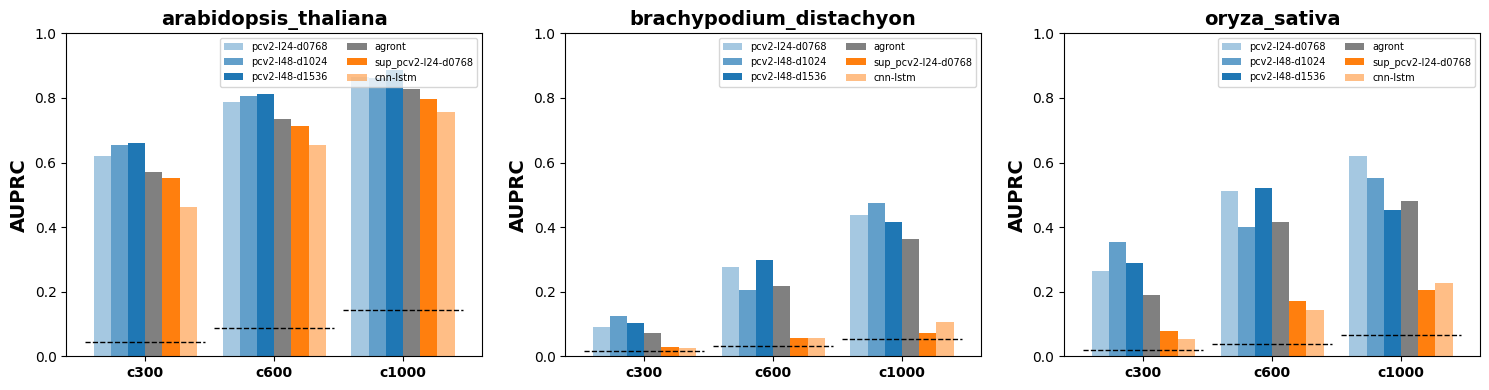

In [11]:
n_sp = len(species)
ncols = 3 
nrows = math.ceil(n_sp / ncols)  

fig, axes = plt.subplots(nrows=nrows, ncols=ncols,
                         figsize=(5 * ncols, 4 * nrows),
                         sharex=True, sharey=True)

axes = np.array(axes).reshape(nrows, ncols)

bar_w = 0.8 / len(ckpts)
x = np.arange(len(contexts))

for idx, sp in enumerate(species):
    row = idx // ncols
    col = idx % ncols
    ax = axes[row, col]

    df_sp = df[df['species'] == sp]

    for i, lab in enumerate(df_sp['model'].unique()):
        sub = df_sp[df_sp['model'] == lab].set_index('context').reindex(contexts).reset_index()
        ax.bar(
            x + i * bar_w,
            sub['ap'],
            bar_w,
            label=f"{lab}",
            color=sub['color'].iloc[0],
            alpha=sub['alpha'].iloc[0]
        )

    for j, ctx in enumerate(contexts):
        baseline = df_sp[df_sp['context'] == ctx]['baseline'].iloc[0]
        ax.hlines(baseline,
                  x[j] - bar_w,
                  x[j] + bar_w * len(ckpts),
                  colors='black', linestyles='--', linewidth=1)

    ax.set_title(sp, fontsize=14, fontweight='bold')
    ax.set_ylabel('AUPRC', fontsize=14, fontweight='bold')
    ax.tick_params(axis='y', labelleft=True)

    tick_pos = x + bar_w * (len(ckpts) - 1) / 2
    ax.set_xticks(tick_pos)
    ax.set_xticklabels(contexts, fontsize=10, rotation=0, ha='center', fontweight='bold')
    ax.tick_params(axis='x', which='both', labelbottom=True)

    ax.set_ylim(0, 1.0)
    ax.legend(loc='upper right', fontsize=7, ncol=2)

for i in range(n_sp, nrows * ncols):
    fig.delaxes(axes.flatten()[i])

plt.tight_layout()
plt.subplots_adjust(hspace=0.25, wspace=0.2)
plt.savefig('../../pipelines/lu_2019_ATACseq/figures/aupr_barplots.pdf', format='pdf', bbox_inches='tight')
plt.show()